In [19]:
# Use Python 3.12

%pip install GAICo

Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd

base_dir = "/home/john/Research/library/data/results/eval"

df_names = [
    "binary_factoid.csv",
    "scenarios/lighthouse_and_informer.csv",
    "scenarios/mccray.csv",
    "scenarios/naacp.csv",
    "scenarios/pdp.csv"
]

dfs = []

for name in df_names:
    dfs.append(pd.read_csv(f"{base_dir}/{name}") )

df = pd.concat(dfs, ignore_index=True)

df = df.dropna()

df




,question,answer,response
0,What year did the Progressive Democratic Party...,1948,"1944\n25th April.\n2 May.\nMarch 4, Oct.1944\n..."
1,What year did the Progressive Democratic Party...,1948,1944
2,What year did the Progressive Democratic Party...,1948,1940\n1960\n1964\n1976 \n1984\n1992\n1998\n1991
3,What year did the Progressive Democratic Party...,1948,1934
4,What year did the Progressive Democratic Party...,1948,"1944, year prior to the Democratic National Co..."
...,...,...,...
265,How did the Progressive Democratic Party impro...,The PDP supported Black political participatio...,The Progressive Democratic Party was...
266,How did the Progressive Democratic Party impro...,The PDP supported Black political participatio...,South Carolina Progressive Democratic Party ma...
267,How did the Progressive Democratic Party impro...,The PDP supported Black political participatio...,It was the Progressive Democratic Party in Cha...
268,How did the Progressive Democratic Party impro...,The PDP supported Black political participatio...,By getting blacks to vote for Democrats. After...


In [21]:
from gaico.metrics import (
    BLEU,
    ROUGE,
    JSDivergence,
    JaccardSimilarity,
    LevenshteinDistance,
    BERTScore,
)

# Initialize metric classes
metric_classes = {
    "bleu": BLEU(),
    "rouge": ROUGE(),
    "js_div": JSDivergence(),
    "jaccard": JaccardSimilarity(),
    "levenshtein": LevenshteinDistance(),
    "bert_score": BERTScore(),
}

In [22]:
def calculate_metrics(ground_truth, prediction):
    return {
        "BLEU": metric_classes["bleu"].calculate(ground_truth, prediction),
        "ROUGE-L": metric_classes["rouge"].calculate(ground_truth, prediction).get("rougeL", 0),
        "JSD": metric_classes["js_div"].calculate(ground_truth, prediction),
        "Jaccard": metric_classes["jaccard"].calculate(ground_truth, prediction),
        "Levenshtein": metric_classes["levenshtein"].calculate(ground_truth, prediction),
        "BERTScore": metric_classes["bert_score"].calculate(ground_truth, prediction).get("f1", 0),
    }

In [23]:
def process_row(row):
    ground_truth = row["answer"]
    return {"model": calculate_metrics(ground_truth, row['response'])}

In [24]:
# Convert DataFrame to list of dictionaries
data = df.to_dict("records")

In [25]:
import concurrent
from tqdm import tqdm
# Use concurrent.futures for parallelization
with concurrent.futures.ThreadPoolExecutor() as executor:
    # Submit all tasks
    future_to_row = {executor.submit(process_row, row): row for row in data}

    # Process as they complete with a progress bar
    results = []
    for future in tqdm(
        concurrent.futures.as_completed(future_to_row),
        total=len(data),
        desc="Processing",
    ):
        results.append(future.result())

Processing: 100%|██████████| 253/253 [00:01<00:00, 192.85it/s]


In [28]:
print(results)

[{'model': {'BLEU': 0.0, 'ROUGE-L': 0.0, 'JSD': 0.1674453888423023, 'Jaccard': 0.0, 'Levenshtein': 0.75, 'BERTScore': 0.8553397059440613}}, {'model': {'BLEU': 0.0, 'ROUGE-L': 0.0, 'JSD': 0.1674453888423023, 'Jaccard': 0.0, 'Levenshtein': 0.18181818181818177, 'BERTScore': 0.44397294521331787}}, {'model': {'BLEU': 0.0, 'ROUGE-L': 0.0, 'JSD': 0.1674453888423023, 'Jaccard': 0.0, 'Levenshtein': 0.11111111111111116, 'BERTScore': 0.2741616368293762}}, {'model': {'BLEU': 0.0, 'ROUGE-L': 0.0, 'JSD': 0.1674453888423023, 'Jaccard': 0.0, 'Levenshtein': 0.07446808510638303, 'BERTScore': 0.2594086527824402}}, {'model': {'BLEU': 0.0, 'ROUGE-L': 0.0, 'JSD': 0.1674453888423023, 'Jaccard': 0.0, 'Levenshtein': 0.06866952789699576, 'BERTScore': 0.290077269077301}}, {'model': {'BLEU': 0.0, 'ROUGE-L': 0.0, 'JSD': 0.1674453888423023, 'Jaccard': 0.0, 'Levenshtein': 0.2068965517241379, 'BERTScore': 0.3144945204257965}}, {'model': {'BLEU': 0.0, 'ROUGE-L': 0.0, 'JSD': 0.1674453888423023, 'Jaccard': 0.0, 'Levensh

In [30]:
records = [d["model"] for d in results]

# Convert to DataFrame
df = pd.DataFrame(records)

# Compute mean of each metric
averages = df.mean()

averages

BLEU           0.001582
ROUGE-L        0.030752
JSD            0.191621
Jaccard        0.017275
Levenshtein    0.093831
BERTScore      0.329054
dtype: float64

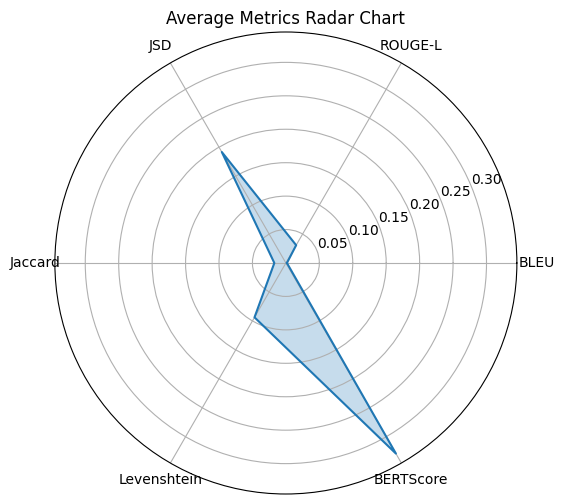

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi
import os
from pathlib import Path


labels = averages.index.tolist()
values = averages.values.astype(float).tolist()
values.append(values[0])  # close the loop

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles.append(angles[0])

# Create radar chart
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Average Metrics Radar Chart")

plt.show()

In [ ]:
# import json
# import os


# metric_names = results[next(iter(results))][0].keys()

# # Compute average for each metric
# all_metrics = {m: [] for m in metric_names}
# for resp_list in results.values():
#     for row_metrics in resp_list:
#         for m in metric_names:
#             v = row_metrics.get(m)
#             if v is not None:
#                 all_metrics[m].append(float(v))

# averages = {
#     m: (sum(vals) / len(vals) if vals else None)
#     for m, vals in all_metrics.items()
# }

# json_path = f"{dir}/accuracy.json"

# os.makedirs(os.path.dirname(json_path), exist_ok=True)

# with open(json_path, "w") as f:
#     json.dump(averages, f, indent=4)

# print(averages)

TypeError: list indices must be integers or slices, not dict

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi
import os
from pathlib import Path

def create_radar_plot(results):
    """
    Creates a radar plot to compare all models across different metrics.

    :param results: A dictionary containing metric scores for each model.
    """
    llm_models = list(results.keys())
    metrics = list(results[llm_models[0]][0].keys())

    # Create a figure
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

    # Number of variables (metrics)
    num_metrics = len(metrics)

    # Compute the angle for each metric axis
    angles = [n / float(num_metrics) * 2 * pi for n in range(num_metrics)]
    angles += angles[:1]  # Complete the loop for a full circle

    # Plot each model's scores
    for model in llm_models:
        metric_scores = [
            np.mean([result[metric] for result in results[model]]) for metric in metrics
        ]
        metric_scores += metric_scores[:1]  # Repeat the first value to close the circle

        # Plot the data for each model
        ax.plot(angles, metric_scores, linewidth=2, linestyle="solid", label=model)
        ax.fill(angles, metric_scores, alpha=0.25)

    # Add the metric labels on the plot
    plt.xticks(angles[:-1], metrics, color="grey", size=12)

    # Set the y-label for the metrics (assuming scores are comparable)
    ax.yaxis.set_tick_params(labelsize=10)
    ax.yaxis.grid(True, color="#DAD8D7")

    # Add a title
    plt.title("M.G.10.NQ2k.03 Accuracy Across Multiple Metrics", size=14, weight="bold", pad=20)

    # Add legend
    plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1), fontsize=12, frameon=False)

    # Set a white background for the figure
    fig.patch.set_facecolor("white")

    # Save the plot
    save_dir = f"{dir}/accuracy/fig.json"
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    plt.savefig(f"{save_dir}/overall_radar_chart.png", bbox_inches="tight")

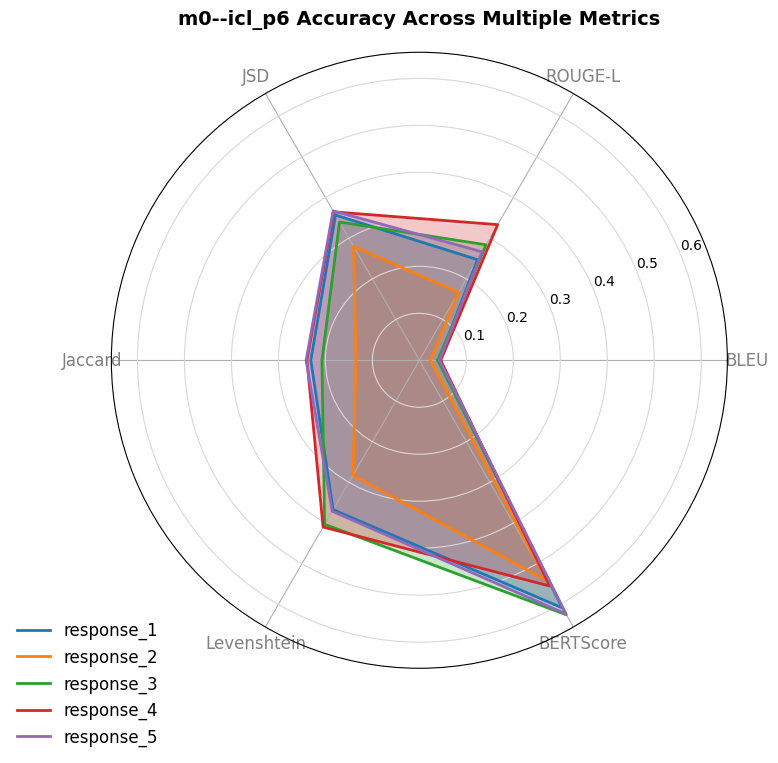

In [ ]:
create_radar_plot(results)